In [1]:
import pandas as pd
import numpy as np

monthly_chunks = pd.read_parquet("monthly_chunks.parquet")
X = np.load("monthly_feat_matrix.npy")

print(monthly_chunks.shape, X.shape)
monthly_chunks.head()

(420, 30) (420, 17)


,symbol,month,start_date,end_date,n_days,curve_logret,curve_cum,feat_month_ret,feat_month_vol,feat_month_mdd,...,ctx_unemployment_change_mean,ctx_unemployment_change_end,ctx_unemployment_change_chg,ctx_pe_ratio_end,ctx_ps_ratio_end,ctx_rev_growth_qoq_end,ctx_volume_change_end,label_next_month_ret,label_next_month_mdd,feat_vec
0,AAPL,2021-07,2021-07-03,2021-07-31,29,"[0.0, 0.0, 0.0, 0.0146112252544602, 0.01779592...","[1.0, 1.0, 1.0, 1.0, 1.0147184909974278, 1.032...",0.042155,0.178651,-0.044921,...,0.0,0.0,0.0,6.172662e-09,1.628193e-09,0.000000,-1.000000,0.040930,-0.031498,"[0.22477113097898765, -0.5335889694717059, 0.5..."
1,AAPL,2021-08,2021-08-01,2021-08-31,31,"[0.0, -0.0023337233462202, 0.0125650382971298,...","[1.0, 1.0, 0.9976689976689976, 1.0102838338132...",0.040930,0.151949,-0.031498,...,0.0,0.0,0.0,6.425307e-09,1.694834e-09,0.000000,0.708916,-0.068037,-0.096943,"[0.21599984617952556, -0.6411139230448345, 0.7..."
2,AAPL,2021-09,2021-09-01,2021-09-30,30,"[0.0044686937739958, 0.0074471209084012, 0.004...","[1.0, 1.0044786932753735, 1.0119870908252648, ...",-0.068037,0.171650,-0.096943,...,0.0,0.0,0.0,6.507542e-09,1.737603e-09,-0.090976,0.443733,0.058657,-0.024606,"[-0.5640694132485541, -0.5617820137476452, 0.0..."
3,AAPL,2021-10,2021-10-01,2021-10-31,31,"[0.0080943605762167, 0.0, 0.0, -0.024913457164...","[1.0, 1.0081272084805655, 1.0081272084805655, ...",0.058657,0.152249,-0.024606,...,0.0,0.0,0.0,6.889257e-09,1.839526e-09,-0.090976,-1.000000,0.103471,-0.031678,"[0.3429083217380599, -0.6399068945017538, 0.78..."
4,AAPL,2021-11,2021-11-01,2021-11-30,30,"[-0.0056232575543622, 0.0070908050127334, 0.00...","[1.0, 0.9943925233644859, 1.0014686248331108, ...",0.103471,0.192010,-0.031678,...,0.0,0.0,0.0,7.602097e-09,2.029865e-09,-0.090976,1.926668,0.074229,-0.054054,"[0.6637237543031062, -0.47979520314802615, 0.7..."


In [2]:
from sklearn.neighbors import NearestNeighbors

# cosine 更适合“方向/形状”相似；euclidean 也可以
nn = NearestNeighbors(n_neighbors=50, metric="cosine")
nn.fit(X)

print("Index built.")

Index built.


In [3]:
import matplotlib.pyplot as plt

def query_similar(symbol: str, month: str, k=10, exclude_self=True):
    """
    symbol: e.g., "AAPL"
    month:  e.g., "2024-11"
    """
    # 找到 query 行
    mask = (monthly_chunks["symbol"] == symbol) & (monthly_chunks["month"] == month)
    if mask.sum() == 0:
        raise ValueError(f"Cannot find chunk for {symbol} {month}. Check available months.")
    q_idx = int(np.where(mask.to_numpy())[0][0])

    q_vec = X[q_idx].reshape(1, -1)
    dist, idx = nn.kneighbors(q_vec, n_neighbors=max(k+5, 20))
    idx = idx.flatten()
    dist = dist.flatten()

    # cosine distance -> similarity
    sim = 1 - dist

    # 过滤自己
    out = []
    for i, s in zip(idx, sim):
        if exclude_self and i == q_idx:
            continue
        out.append((i, float(s)))
        if len(out) >= k:
            break

    # 组装结果表
    rows = []
    for i, s in out:
        r = monthly_chunks.iloc[i]
        rows.append({
            "rank": len(rows)+1,
            "similarity": s,
            "symbol": r["symbol"],
            "month": r["month"],
            "start_date": r["start_date"],
            "end_date": r["end_date"],
            "feat_month_ret": r["feat_month_ret"],
            "feat_month_vol": r["feat_month_vol"],
            "feat_month_mdd": r["feat_month_mdd"],
            "label_next_month_ret": r["label_next_month_ret"],
            "label_next_month_mdd": r["label_next_month_mdd"],
        })
    res = pd.DataFrame(rows)

    # 预测：用 similarity 做加权平均（也给分位数）
    neigh_ret = res["label_next_month_ret"].astype(float)
    w = res["similarity"].astype(float).clip(lower=0)
    w = w / (w.sum() + 1e-12)

    pred_mean = float((w * neigh_ret).sum())
    pred_p10 = float(neigh_ret.quantile(0.10))
    pred_p50 = float(neigh_ret.quantile(0.50))
    pred_p90 = float(neigh_ret.quantile(0.90))

    # 证据包：曲线对比（query vs top1）
    q_row = monthly_chunks.iloc[q_idx]
    top1_row = monthly_chunks.iloc[out[0][0]]

    q_curve = np.array(q_row["curve_cum"], dtype=float)
    t_curve = np.array(top1_row["curve_cum"], dtype=float)

    # 归一化到1起点（已经是从1开始，但保险）
    q_curve = q_curve / (q_curve[0] if q_curve[0] != 0 else 1.0)
    t_curve = t_curve / (t_curve[0] if t_curve[0] != 0 else 1.0)

    evidence = {
        "query": {"symbol": symbol, "month": month},
        "top1": {"symbol": top1_row["symbol"], "month": top1_row["month"], "similarity": out[0][1]},
        "pred": {"mean": pred_mean, "p10": pred_p10, "p50": pred_p50, "p90": pred_p90},
        "q_curve": q_curve,
        "top1_curve": t_curve
    }

    return res, evidence

def plot_query_vs_top1(evidence):
    q = evidence["query"]
    t = evidence["top1"]
    q_curve = evidence["q_curve"]
    t_curve = evidence["top1_curve"]

    plt.figure(figsize=(9,3.5))
    plt.plot(q_curve, label=f"Query {q['symbol']} {q['month']}")
    plt.plot(t_curve, label=f"Top1 {t['symbol']} {t['month']} (sim={t['similarity']:.3f})")
    plt.title("Monthly Pattern Shape: Query vs Top-1 Similar Month")
    plt.xlabel("Day in month (index)")
    plt.ylabel("Normalized cumulative (start=1)")
    plt.grid(True)
    plt.legend()
    plt.show()

In [4]:
res, evidence = query_similar("AAPL", "2024-11", k=10)
res

,rank,similarity,symbol,month,start_date,end_date,feat_month_ret,feat_month_vol,feat_month_mdd,label_next_month_ret,label_next_month_mdd
0,1,0.915144,MSFT,2024-11,2024-11-01,2024-11-30,0.042107,0.149969,-0.032842,-0.004629,-0.072526
1,2,0.773160,TSM,2023-03,2023-03-01,2023-03-31,0.068336,0.226279,-0.045470,-0.093743,-0.115782
2,3,0.772982,GOOGL,2023-12,2023-12-01,2023-12-31,0.054026,0.200612,-0.036442,0.002935,-0.087356
3,4,0.733556,GOOGL,2024-06,2024-06-01,2024-06-30,0.055942,0.140193,-0.017583,-0.058249,-0.126478
4,5,0.721462,QCOM,2023-12,2023-12-01,2023-12-31,0.120728,0.146859,-0.019479,0.026827,-0.058494
5,6,0.718059,TXN,2023-03,2023-03-01,2023-03-31,0.084923,0.178343,-0.025990,-0.101124,-0.115854
6,7,0.717160,MSFT,2023-12,2023-12-01,2023-12-31,-0.007574,0.114457,-0.034256,0.057281,-0.029630
7,8,0.710325,AAPL,2023-03,2023-03-01,2023-03-31,0.118649,0.187231,-0.034649,0.028987,-0.036529
8,9,0.696421,GOOGL,2023-07,2023-07-01,2023-07-31,0.108772,0.259220,-0.049593,0.025995,-0.039632
9,10,0.694582,MSFT,2023-03,2023-03-01,2023-03-31,0.155882,0.221252,-0.032234,0.065765,-0.055487


Prediction (next month return): {'mean': -0.006035260314843306, 'p10': -0.09448131246391403, 'p50': 0.014464822779243547, 'p90': 0.05812950910418537}


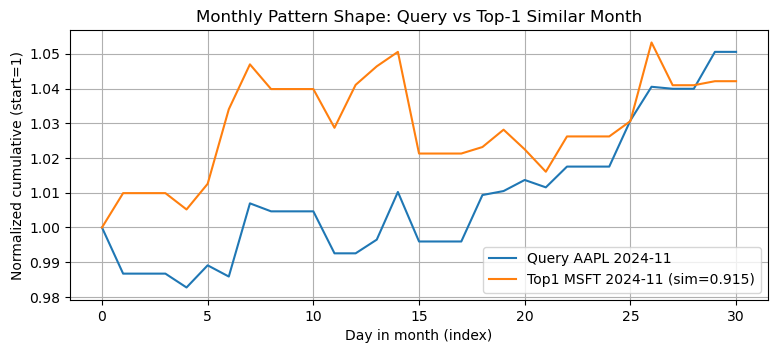

In [5]:
print("Prediction (next month return):", evidence["pred"])
plot_query_vs_top1(evidence)

In [6]:
import numpy as np
import pandas as pd

def curve_metrics(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    n = min(len(a), len(b))
    a, b = a[:n], b[:n]
    # 归一化到同起点
    a = a / (a[0] if a[0]!=0 else 1.0)
    b = b / (b[0] if b[0]!=0 else 1.0)
    corr = np.corrcoef(a, b)[0,1]
    mse = float(np.mean((a - b)**2))
    # 最大回撤位置
    def mdd_pos(x):
        peak = np.maximum.accumulate(x)
        dd = x/peak - 1
        i = int(np.argmin(dd))
        return float(dd[i]), i
    mdd_a, pos_a = mdd_pos(a)
    mdd_b, pos_b = mdd_pos(b)
    return {
        "curve_corr": float(corr),
        "curve_mse": mse,
        "mdd_query": mdd_a, "mdd_day_query": pos_a,
        "mdd_top1": mdd_b, "mdd_day_top1": pos_b,
        "len_days_used": n
    }

metrics = curve_metrics(evidence["q_curve"], evidence["top1_curve"])
metrics

{'curve_corr': 0.5506787733111177,
 'curve_mse': 0.0006815643230554167,
 'mdd_query': -0.017263512018060312,
 'mdd_day_query': 4,
 'mdd_top1': -0.03284218416922402,
 'mdd_day_top1': 21,
 'len_days_used': 31}

In [7]:
# 取 query / top1 的 row
q_sym, q_mon = evidence["query"]["symbol"], evidence["query"]["month"]
t_sym, t_mon = evidence["top1"]["symbol"], evidence["top1"]["month"]

q_row = monthly_chunks[(monthly_chunks["symbol"]==q_sym) & (monthly_chunks["month"]==q_mon)].iloc[0]
t_row = monthly_chunks[(monthly_chunks["symbol"]==t_sym) & (monthly_chunks["month"]==t_mon)].iloc[0]

cols = [c for c in monthly_chunks.columns if c.startswith("ctx_")] + [
    "feat_month_ret","feat_month_vol","feat_month_mdd","feat_trend_slope",
    "feat_ret_first_half","feat_ret_second_half","feat_vol20_chg"
]
cols = [c for c in cols if c in monthly_chunks.columns]

compare = pd.DataFrame({
    "Query": [q_row[c] for c in cols],
    "Top1":  [t_row[c] for c in cols],
}, index=cols)

compare

,Query,Top1
ctx_real_rate_mean,5.236616e-01,5.236616e-01
ctx_real_rate_end,5.236616e-01,5.236616e-01
ctx_real_rate_chg,0.000000e+00,0.000000e+00
ctx_yield_curve_mean,-2.800000e-01,-2.800000e-01
ctx_yield_curve_end,-2.800000e-01,-2.800000e-01
ctx_yield_curve_chg,0.000000e+00,0.000000e+00
ctx_unemployment_change_mean,-7.936508e-04,-7.936508e-04
ctx_unemployment_change_end,0.000000e+00,0.000000e+00
ctx_unemployment_change_chg,2.380952e-02,2.380952e-02
ctx_pe_ratio_end,1.106537e-08,1.921674e-08
